### Задание

Создайте систему компьютерного зрения, которая будет определять тип геометрической фигуры. Используя подготовленную базу и шаблон ноутбука проведите серию экспериментов по перебору гиперпараметров нейронной сети, распознающей три категории изображений (треугольник, круг, квадрат).

1. Поменяйте количество нейронов в сети, используя следующие значения:

- один слой 10 нейронов
- один слой 100 нейронов
- один слой 5000 нейронов.

2. Поменяйте активационную функцию в скрытых слоях с `relu` на `linear`.
3. Поменяйте размеры batch_size:
- 10
- 100
- 1000

4. Выведите на экран получившиеся точности.

Всего должно получиться 18 комбинаций указанных параметров.

Создайте сравнительную таблицу по результатам проведенных тестов.

In [1]:
# Подключение библиотек
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')

# TensorFlow/Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import utils
from tensorflow.keras.preprocessing import image
from tensorflow.keras.optimizers import Adam

# Для отрисовки
%matplotlib inline

In [2]:
# Загрузка датасета
import gdown
url = 'https://drive.google.com/uc?id=1yt_hr4AYEWbjtmYfTNSlEkxl5JaFuYEX'
gdown.download(url, 'hw_light.zip', quiet=False)
!unzip -o -q hw_light.zip

print("Данные загружены!")

Downloading...
From: https://drive.google.com/uc?id=1yt_hr4AYEWbjtmYfTNSlEkxl5JaFuYEX
To: /content/hw_light.zip
100%|██████████| 304k/304k [00:00<00:00, 65.3MB/s]

Данные загружены!


In [3]:
base_dir = '/content/hw_light'
x_train, y_train = [], []
img_height, img_width = 20, 20

print("Загрузка изображений...")
for patch in os.listdir(base_dir):
    patch_path = os.path.join(base_dir, patch)
    if os.path.isdir(patch_path):
        for img_file in os.listdir(patch_path):
            img = image.load_img(
                os.path.join(patch_path, img_file),
                target_size=(img_height, img_width),
                color_mode='grayscale'
            )
            x_train.append(image.img_to_array(img))

            if patch == '0':
                y_train.append(0)  # 0 = КРУГ
            elif patch == '3':
                y_train.append(1)  # 1 = ТРЕУГОЛЬНИК
            else:  # patch == '1'
                y_train.append(2)  # 2 = КВАДРАТ

x_train = np.array(x_train)
y_train = np.array(y_train)

print(f'Изображений: {x_train.shape}')
print(f'Меток: {y_train.shape}')

Загрузка изображений...
Изображений: (302, 20, 20, 1)
Меток: (302,)


In [4]:
CLASS_COUNT = 3

# Преобразование в вектор
x_train = x_train.reshape(x_train.shape[0], -1)
print(f'После reshape: {x_train.shape}')

# Нормализация
x_train = x_train.astype('float32') / 255.
print(f'Нормализация: [{x_train.min():.2f}, {x_train.max():.2f}]')

# One-hot encoding
y_train_cat = utils.to_categorical(y_train, CLASS_COUNT)
print(f'One-hot: {y_train_cat.shape}')

После reshape: (302, 400)
Нормализация: [0.00, 1.00]
One-hot: (302, 3)


In [5]:
# Перемешивание
np.random.seed(42)
indices = np.random.permutation(len(x_train))
x_train = x_train[indices]
y_train_cat = y_train_cat[indices]

# Разделение 80/20
val_size = int(0.2 * len(x_train))

x_train_split = x_train[val_size:]
y_train_split = y_train_cat[val_size:]

x_val = x_train[:val_size]
y_val = y_train_cat[:val_size]

print(f'Обучающая: {x_train_split.shape}')
print(f'Валидационная: {x_val.shape}')

Обучающая: (242, 400)
Валидационная: (60, 400)


In [6]:
def create_model(neurons, activation='relu'):
    model = Sequential()
    model.add(Dense(neurons,
                   input_dim=400,
                   activation=activation,
                   name='hidden_layer'))
    model.add(Dense(CLASS_COUNT,
                   activation='softmax',
                   name='output'))
    return model

In [7]:
def train_and_evaluate(neurons, activation, batch_size, epochs=50):
    model = create_model(neurons, activation)

    model.compile(loss='categorical_crossentropy',
                 optimizer=Adam(learning_rate=0.001),
                 metrics=['accuracy'])

    history = model.fit(x_train_split, y_train_split,
                       batch_size=batch_size,
                       epochs=epochs,
                       validation_data=(x_val, y_val),
                       verbose=0)

    best_acc = max(history.history['val_accuracy'])
    return best_acc

In [8]:
# Параметры для перебора
neurons_list = [10, 100, 5000]
activations = ['relu', 'linear']
batch_sizes = [10, 100, 1000]

results = []

total = len(neurons_list) * len(activations) * len(batch_sizes)
current = 0

for neurons in neurons_list:
    for activation in activations:
        for batch_size in batch_sizes:
            current += 1
            print(f"\n[{current}/{total}] {neurons} нейр., {activation}, batch={batch_size}")

            try:
                accuracy = train_and_evaluate(neurons, activation, batch_size, epochs=50)
                results.append({
                    'Нейронов': neurons,
                    'Активация': activation,
                    'Batch Size': batch_size,
                    'Точность': round(accuracy, 4)
                })
                print(f"✓ Точность: {accuracy:.4f}")
            except Exception as e:
                print(f"✗ Ошибка: {e}")
                results.append({
                    'Нейронов': neurons,
                    'Активация': activation,
                    'Batch Size': batch_size,
                    'Точность': 0.0
                })


[1/18] 10 нейр., relu, batch=10
✓ Точность: 0.8000

[2/18] 10 нейр., relu, batch=100
✓ Точность: 0.8000

[3/18] 10 нейр., relu, batch=1000
✓ Точность: 0.7333

[4/18] 10 нейр., linear, batch=10
✓ Точность: 0.7667

[5/18] 10 нейр., linear, batch=100
✓ Точность: 0.7333

[6/18] 10 нейр., linear, batch=1000
✓ Точность: 0.6000

[7/18] 100 нейр., relu, batch=10
✓ Точность: 0.8500

[8/18] 100 нейр., relu, batch=100
✓ Точность: 0.8167

[9/18] 100 нейр., relu, batch=1000
✓ Точность: 0.7667

[10/18] 100 нейр., linear, batch=10
✓ Точность: 0.7500

[11/18] 100 нейр., linear, batch=100
✓ Точность: 0.7333

[12/18] 100 нейр., linear, batch=1000
✓ Точность: 0.7500

[13/18] 5000 нейр., relu, batch=10
✓ Точность: 0.8500

[14/18] 5000 нейр., relu, batch=100
✓ Точность: 0.8667

[15/18] 5000 нейр., relu, batch=1000
✓ Точность: 0.8167

[16/18] 5000 нейр., linear, batch=10
✓ Точность: 0.7333

[17/18] 5000 нейр., linear, batch=100
✓ Точность: 0.7667

[18/18] 5000 нейр., linear, batch=1000
✓ Точность: 0.7500


In [9]:
# Создание DataFrame
df = pd.DataFrame(results)

# Сортировка по точности
df_sorted = df.sort_values('Точность', ascending=False).reset_index(drop=True)

print("СРАВНИТЕЛЬНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("=" * 80)
print(df_sorted.to_string(index=True))
print("=" * 80)

# Сохранение
df_sorted.to_csv('experiment_results_correct.csv', index=False)
print("\nТаблица сохранена")

# Сводная таблица
pivot = df.pivot_table(values='Точность',
                       index=['Нейронов', 'Активация'],
                       columns='Batch Size',
                       aggfunc='mean').round(4)
print("\nСводная таблица:")
print(pivot)

СРАВНИТЕЛЬНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
    Нейронов Активация  Batch Size  Точность
0       5000      relu         100    0.8667
1        100      relu          10    0.8500
2       5000      relu          10    0.8500
3        100      relu         100    0.8167
4       5000      relu        1000    0.8167
5         10      relu          10    0.8000
6         10      relu         100    0.8000
7       5000    linear         100    0.7667
8         10    linear          10    0.7667
9        100      relu        1000    0.7667
10      5000    linear        1000    0.7500
11       100    linear        1000    0.7500
12       100    linear          10    0.7500
13        10      relu        1000    0.7333
14       100    linear         100    0.7333
15        10    linear         100    0.7333
16      5000    linear          10    0.7333
17        10    linear        1000    0.6000

Таблица сохранена

Сводная таблица:
Batch Size            10      100     1000
Нейронов Активация             

In [13]:
best_params = df_sorted.iloc[0]
print(f"Лучшая комбинация:")
print(f"   Нейронов: {best_params['Нейронов']}")
print(f"   Активация: {best_params['Активация']}")
print(f"   Batch Size: {best_params['Batch Size']}")
print(f"   Точность: {best_params['Точность']:.4f}")

best_model = create_model(int(best_params['Нейронов']), best_params['Активация'])
best_model.compile(loss='categorical_crossentropy',
                  optimizer=Adam(learning_rate=0.001),
                  metrics=['accuracy'])

history = best_model.fit(x_train_split, y_train_split,
                        batch_size=int(best_params['Batch Size']),
                        epochs=50,
                        validation_data=(x_val, y_val),
                        verbose=1)

best_model.save_weights('best_model_correct.weights.h5')
class_names = ['КРУГ', 'ТРЕУГОЛЬНИК', 'КВАДРАТ']

Лучшая комбинация:
   Нейронов: 5000
   Активация: relu
   Batch Size: 100
   Точность: 0.8667
Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 464ms/step - accuracy: 0.3436 - loss: 2.7610 - val_accuracy: 0.5333 - val_loss: 1.3686
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4956 - loss: 1.8221 - val_accuracy: 0.6667 - val_loss: 0.7763
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6934 - loss: 0.8834 - val_accuracy: 0.5500 - val_loss: 1.3587
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6472 - loss: 1.4295 - val_accuracy: 0.6500 - val_loss: 0.8097
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7921 - loss: 0.7392 - val_accuracy: 0.5167 - val_loss: 0.9504
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5805 - loss: 0.8325 - val_accuracy: 0.7167 - val_loss: 0.7894
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7082 - loss: 0.6339 - val_accuracy: 0.7000 - val_loss: 0.6604
Epoch 8/50
3/3 ━━━━━━━━━━━━━━

Итоговая точность на валидации: 0.8667 (86.7%)


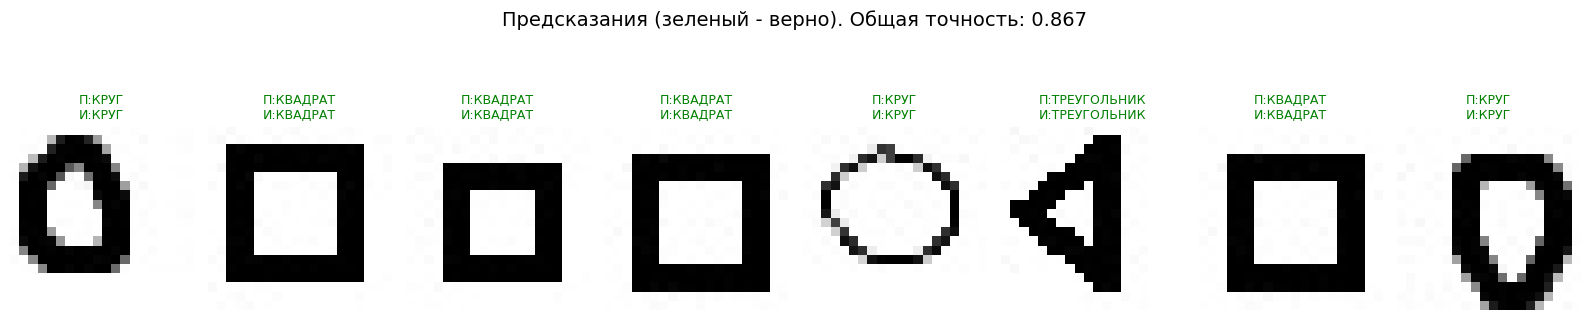

In [14]:
# Оценка на валидации
val_loss, val_acc = best_model.evaluate(x_val, y_val, verbose=0)
print(f"Итоговая точность на валидации: {val_acc:.4f} ({val_acc*100:.1f}%)")

# Покажем несколько предсказаний
plt.figure(figsize=(16, 4))
for i in range(8):
    idx = np.random.randint(len(x_val))
    img = x_val[idx].reshape(20, 20)
    true = np.argmax(y_val[idx])
    pred = np.argmax(best_model.predict(x_val[idx].reshape(1, -1), verbose=0)[0])

    plt.subplot(1, 8, i+1)
    plt.imshow(img, cmap='gray')
    color = 'green' if pred == true else 'red'
    plt.title(f'П:{class_names[pred]}\nИ:{class_names[true]}', color=color, fontsize=9)
    plt.axis('off')
plt.suptitle(f'Предсказания (зеленый - верно). Общая точность: {val_acc:.3f}', fontsize=14)
plt.tight_layout()
plt.show()